# EEG based classification of Digit-Span Memorization vs. Listening

### Acknowledgements

This data has been downloaded from:

Yuri G. Pavlov, Dauren Kasanov, Alexandra I. Kosachenko, and Alexander I. Kotyusov (2024). EEG, pupillometry, ECG and photoplethysmography, and behavioral data in the digit span task and rest. OpenNeuro. [Dataset] doi: doi:10.18112/openneuro.ds003838.v1.0.6

https://openneuro.org/datasets/ds003838/versions/1.0.6

### Import libraries

In [2]:
import mne
import pandas as pd
import csv
import matplotlib.pyplot as plt
import warnings
import os
import numpy as np
from mne_icalabel import label_components
from IPython.display import display
import traceback
from sklearn.model_selection import RandomizedSearchCV, LeaveOneGroupOut
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier

mne.set_log_level("ERROR")
warnings.filterwarnings("ignore", category=UserWarning, module="pymatreader")

c:\Users\atifm\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Intro

"This dataset consists of raw 64-channel EEG, cardiovascular (electrocardiography and photoplethysmography), and pupillometry data from 86 human participants during 4 minutes of eyes-closed resting and during performance of a classic working memory task – digit span task with serial recall. The participants either memorized (memory) or just listened to (control condition) sequences of 5, 9, or 13 digits presented auditorily with 2 second stimulus onset asynchrony. The dataset can be used for (1) developing algorithms for cognitive load discrimination and detection of cognitive overload; (2) studying neural (event-related potentials and brain oscillations) and peripheral physiological (electrocardiography, photoplethysmography, and pupillometry) signals during encoding and maintenance of each sequentially presented memory item in a fine time scale; (3) correlating cognitive load and individual differences in working memory to neural and peripheral physiology, and studying the relationship between the physiological signals; (4) integration of the physiological findings with the vast knowledge coming from behavioral studies of verbal working memory in simple span paradigms.

EEG, pupillometry, ECG and photoplethysmography, and behavioral data are stored separately in corresponding folders. Each data record can consist of four data folders: beh - behavioral data: correctness of the recall in the memory trials ecg - electrocardiography (ECG) and photoplethysmography (PPG) data eeg - EEG data pupil - pupillometry and eye-tracking data

Some of the participants had some physiological data missing: sub-017, sub-094 have no pupillometry data sub-017, sub-037, sub-066 have no ECG and PPG data sub-013, sub-014, sub-015, sub-016, sub-017, sub-018, sub-019, sub-020, sub-021, sub-022, sub-023, sub-024, sub-025, sub-026, sub-027, sub-028, sub-029, sub-030, sub-031, sub-037, sub-066 have no EEG data"

Yuri G. Pavlov, Dauren Kasanov, Alexandra I. Kosachenko, and Alexander I. Kotyusov (2024). EEG, pupillometry, ECG and photoplethysmography, and behavioral data in the digit span task and rest. OpenNeuro. [Dataset] doi: doi:10.18112/openneuro.ds003838.v1.0.6

## EDA

### EDA code

In [73]:
# The EEG data is in the `_eeg.set` files
participants = [32, 33, 34, 35, 36, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65]
eeg_eda_df = []

for participant in participants:
    file = f"data/sub-0{participant}/eeg/sub-0{participant}_task-memory_eeg.set"
    if os.path.exists(file):
        raw = mne.io.read_raw_eeglab(file, preload=True)
        eeg_eda = {"participant" : {participant}, "channels": raw.ch_names, "num_channels" : {len(raw.ch_names)}, "num_readings" : raw.n_times, "frequency" : raw.info["sfreq"]}
        eeg_eda_df.append(eeg_eda)
    else:
        print(f"ERROR: EEG file DOES NOT EXIST for participant {participant}!")

eeg_eda_df_summary = pd.DataFrame(eeg_eda_df)
display(eeg_eda_df_summary)
display(eeg_eda_df_summary.describe(include="all"))
print(eeg_eda_df_summary["channels"][0])

,participant,channels,num_channels,num_readings,frequency
0,{32},"[Fp1, Fz, F3, F7, FT9, FC5, FC1, C3, T7, TP9, ...",{63},7395320,1000.0
1,{33},"[Fp1, Fz, F3, F7, FT9, FC5, FC1, C3, T7, TP9, ...",{63},8446880,1000.0
2,{34},"[Fp1, Fz, F3, F7, FT9, FC5, FC1, C3, T7, TP9, ...",{63},7084360,1000.0
3,{35},"[Fp1, Fz, F3, F7, FT9, FC5, FC1, C3, T7, TP9, ...",{63},7342940,1000.0
4,{36},"[Fp1, Fz, F3, F7, FT9, FC5, FC1, C3, T7, TP9, ...",{63},7382180,1000.0
5,{38},"[Fp1, Fz, F3, F7, FT9, FC5, FC1, C3, T7, TP9, ...",{63},6951940,1000.0
6,{39},"[Fp1, Fz, F3, F7, FT9, FC5, FC1, C3, T7, TP9, ...",{63},7182840,1000.0
7,{40},"[Fp1, Fz, F3, F7, FT9, FC5, FC1, C3, T7, TP9, ...",{63},7176340,1000.0
8,{41},"[Fp1, Fz, F3, F7, FT9, FC5, FC1, C3, T7, TP9, ...",{63},8204060,1000.0
9,{42},"[Fp1, Fz, F3, F7, FT9, FC5, FC1, C3, T7, TP9, ...",{63},9603300,1000.0


,participant,channels,num_channels,num_readings,frequency
count,33,33,33,3.300000e+01,33.0
unique,33,1,1,NaN,NaN
top,{32},"[Fp1, Fz, F3, F7, FT9, FC5, FC1, C3, T7, TP9, ...",{63},NaN,NaN
freq,1,33,33,NaN,NaN
mean,NaN,NaN,NaN,7.637856e+06,1000.0
std,NaN,NaN,NaN,5.456416e+05,0.0
min,NaN,NaN,NaN,6.951940e+06,1000.0
25%,NaN,NaN,NaN,7.314740e+06,1000.0
50%,NaN,NaN,NaN,7.484940e+06,1000.0
75%,NaN,NaN,NaN,7.927420e+06,1000.0


['Fp1', 'Fz', 'F3', 'F7', 'FT9', 'FC5', 'FC1', 'C3', 'T7', 'TP9', 'CP5', 'CP1', 'Pz', 'P3', 'P7', 'O1', 'Oz', 'O2', 'P4', 'P8', 'TP10', 'CP6', 'CP2', 'Cz', 'C4', 'T8', 'FT10', 'FC6', 'FC2', 'F4', 'F8', 'Fp2', 'AF7', 'AF3', 'AFz', 'F1', 'F5', 'FT7', 'FC3', 'C1', 'C5', 'TP7', 'CP3', 'P1', 'P5', 'PO7', 'PO3', 'POz', 'PO4', 'PO8', 'P6', 'P2', 'CPz', 'CP4', 'TP8', 'C6', 'C2', 'FC4', 'FT8', 'F6', 'AF8', 'AF4', 'F2']


### EDA conlusion



- We will use 33 participants for our analysis
- Each participant has a 64-channel EEG recording (we have 63 channels because one electrode is a reference)
- The EEG data is recorded at 1000Hz
- The number of EEG data points is between 6951940.0 and 9603300.0 (mean = 7637856.363636363)
- The EEG channels are `['Fp1', 'Fz', 'F3', 'F7', 'FT9', 'FC5', 'FC1', 'C3', 'T7', 'TP9', 'CP5', 'CP1', 'Pz', 'P3', 'P7', 'O1', 'Oz', 'O2', 'P4', 'P8', 'TP10', 'CP6', 'CP2', 'Cz', 'C4', 'T8', 'FT10', 'FC6', 'FC2', 'F4', 'F8', 'Fp2', 'AF7', 'AF3', 'AFz', 'F1', 'F5', 'FT7', 'FC3', 'C1', 'C5', 'TP7', 'CP3', 'P1', 'P5', 'PO7', 'PO3', 'POz', 'PO4', 'PO8', 'P6', 'P2', 'CPz', 'CP4', 'TP8', 'C6', 'C2', 'FC4', 'FT8', 'F6', 'AF8', 'AF4', 'F2']`
- The set of electrodes is consistent across participants

## EEG pre-processing

### Load, filter, and re-reference data

In [ ]:
participants = [32, 33, 34, 35, 36, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65]
print(f"N =  {len(participants)}")

cache_dir = "data/filtered-referenced-eeg"
os.makedirs(cache_dir, exist_ok=True)

for participant in participants:
    cached_file = f"{cache_dir}/sub-0{participant}-task-eeg_filtered-referenced.fif"

    if os.path.exists(cached_file):
        print("File exists!")
    else:
        # Cached, pre-processed file not found: load raw file
        file = f"data/sub-0{participant}/eeg/sub-0{participant}_task-memory_eeg.set"
        raw = mne.io.read_raw_eeglab(file, preload=True)

        # Frequency filter: High-pass 1Hz, Low-pass 45Hz & re-reference to averaged reference
        # Based on the original authors' implementation: (Kosachenko et al., 2023)
        raw.filter(l_freq=1, h_freq=45)
        raw.set_eeg_reference("average")

        # Save file to cache
        raw.save(cached_file, overwrite=True)

### ICA and epoching

In [ ]:
participant = 40
cache_dir = "data/filtered-referenced-eeg"
cached_file = f"{cache_dir}/sub-0{participant}-task-eeg_filtered-referenced.fif"

if os.path.exists(cached_file):
    print(f"Found file {cached_file}")
    raw = mne.io.read_raw_fif(cached_file, preload=True)
    ica = mne.preprocessing.ICA(n_components=0.99, method="fastica", random_state=42)
    ica.fit(raw)
    ica.plot_components()
    ica_labels = label_components(raw, ica, "iclabel")
    display(ica_labels)
else:
    print(f"File - {cached_file} not found!")


In [ ]:
display(pd.DataFrame(ica_labels))

#### For each participant remove the artifacts using mne-icalabel

In [ ]:
cache_dir = "data/filtered-referenced-eeg"
target_dir = "data/ica-excluded-eeg"
os.makedirs(target_dir, exist_ok=True)

participants = [32, 33, 34, 35, 36, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65]
ica_components = []

for participant in participants:
    cached_file = f"{cache_dir}/sub-0{participant}-task-eeg_filtered-referenced.fif"
    target_file = f"{target_dir}/sub-0{participant}-task-eeg_ica-cleaned.fif"
    if os.path.exists(target_file):
        print(f"ICA cleaned file exists for {participant} - {target_file}. Skipping...")
        continue
    if os.path.exists(cached_file):
        try:
            print(f"Found file {cached_file}")
            raw = mne.io.read_raw_fif(cached_file, preload=True)
            ica = mne.preprocessing.ICA(n_components=0.99, method="fastica", random_state=42)
            ica.fit(raw)
            ica_components.append(ica.n_components)
            ica_labels = label_components(raw, ica, "iclabel")
            excluded_components = []
            for idx, label in enumerate(ica_labels["labels"]):
                if label != "brain":
                    excluded_components.append(idx)
                    print(f"Excluding index {idx} from {participant} because label is {label}")
            print(f"For participant {participant}, we are excluding components {excluded_components}")
            ica.exclude = excluded_components
            eeg_ica_cleaned = ica.apply(raw.copy())
            eeg_ica_cleaned.save(target_file, overwrite=True)
            print(f"@ Saved file {target_file}")
        except Exception as error:
            print(f"Error {error} while trying to apply ICA to participant {participant}")
    else:
        print(f"File - {cached_file} not found!")

#### Epoching the data

In [ ]:
## LABEL = the event string like x500913
## CODE = a numeric code of the event

def parse_label(label):
    if not label.startswith(("5", "6")) or len(label) > 7 or len(label) < 6:
        print(f"Skipping this label: label {label} is invalid.")
        return None
    condition_flag = label[0]
    if condition_flag not in ("5", "6"):
        print(f"Error: label {label}. Condition flag is invalid")
    condition = "Memory" if condition_flag == "6" else "Listen"
    position = int(label[2:4])
    load = int(label[4:6])
    correct = None
    if condition == "Memory" and len(label) > 6:
        correct = "Correct" if label[6] == "1" else "Incorrect"
    return {"label" : label, "condition" : condition, "position" : position, "load" : load, "correct" : correct}


def compute_power(epochs):
    freq = np.concatenate([np.arange(8, 13, 2), np.arange(30, 45, 2)]) # Alpha and Gamma. We are using 45 because we cutoff after that in our filter. Sparser sampling.
    n_cycles = freq / 2
    powers = epochs.compute_tfr(method="morlet", freqs=freq, n_cycles=n_cycles, decim=4, average=False)
    powers.data = powers.data.astype(np.float32)
    # Compute power relative to a time window
    powers.apply_baseline(baseline=(-1.5, -0.2), mode="logratio")
    
    # Crop to get Alpha (8-12) and Gamma (30-44). Average across time, frequencies, channels
    # This will give me a single value for whole scalp
    # FUTURE TODO: average over regions to get ROI specific values
    alpha_mean = powers.copy().crop(fmin=8, fmax=12).data.mean(axis=(1, 2, 3))
    gamma_mean = powers.copy().crop(fmin=30, fmax=44).data.mean(axis=(1, 2, 3))

    return pd.DataFrame({"alpha_power" : alpha_mean, "gamma_power" : gamma_mean})


preprocessed_eeg_dir = "data/ica-excluded-eeg"
def process_participant_data(num):
    print(f"Processing epoch for participant {num}")
    eeg_file = f"{preprocessed_eeg_dir}/sub-0{num}-task-eeg_ica-cleaned.fif"
    if not os.path.exists(eeg_file):
        print(f"File {eeg_file} not found")
    else:
        raw = mne.io.read_raw_fif(eeg_file, preload=True)
        print(f"Read file {eeg_file}")
        events, event_id = mne.events_from_annotations(raw)
        code_to_label = {v : k for k, v in event_id.items()} # Reverse map. Get a dict where event "code" is KEY and "label" is VALUE

    # Loop through events in time series
    metadata, valid_event_indices = [], []
    for index, event in enumerate(events):
        event_description = parse_label(code_to_label[event[2]]) # Get the label from the event code which is in the 3rd position in "event"
        if event_description:
            metadata.append(event_description)
            valid_event_indices.append(index)
    
    metadata_df = pd.DataFrame(metadata) # Create metadata dataframe
    valid_events = events[valid_event_indices] # Get the list of clean event codes
    matched_event_labels = {k: v for k, v in event_id.items() if parse_label(k)} # Get the dictionary of event labels to codes, but only where it's valid label

    # Create epoch object: from 1.5 before to 3.5 as authors did
    epochs = mne.Epochs(raw, events=valid_events, event_id=matched_event_labels, tmin=-1.5, tmax=3.5, metadata=metadata_df)
    
    print(f"Start computing power for participant {num}")
    powers = compute_power(epochs)
    participant_df = epochs.metadata.reset_index(drop=True).copy()
    participant_df["alpha_power"] = powers["alpha_power"].values
    participant_df["gamma_power"] = powers["gamma_power"].values
    participant_df["participant"] = num
    print(f"\nBelow is dataframe for participant {num}")
    display(participant_df)
    return participant_df

participants_batch_1 = [32, 33, 34, 35, 36, 38, 39, 40, 41, 42]
participants_batch_2 = [43, 44, 45, 46, 47, 48, 49, 50, 51, 52]
participants_batch_3 = [53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65] # We will leave this out for lack of time

all_participants = []

print(f"Starting batch_1. all_participants shape: {len(all_participants)}")
for participant in participants_batch_1:
    print(f"\n\nProcessing epoch and power for participant {participant}")
    # try:
    all_participants.append(process_participant_data(participant))
    # except Exception as error:
    #    print(f"Skipped participant {participant}. Error {error}.")

print(f"Starting batch_2. all_participants shape: {len(all_participants)}")
for participant in participants_batch_2:
    print(f"\nProcessing epoch and power for participant {participant}")
    try:
        all_participants.append(process_participant_data(participant))
    except Exception as error:
        print(f"Skipped participant {participant}. Error {error}.")

all_participants_df = pd.concat(all_participants, ignore_index=True)
display(all_particpants)



In [ ]:
print(f"all_participants shape is {len(all_participants)}")
display(all_participants[0])
print(f"all_participants_df shape os {all_participants_df.shape}")
all_participants_df.to_csv("eeg-power-features.csv", index=False)

#### Test cases

In [ ]:
## Test the parse function : IT WORKS! :)
# labels = ["x500813", "x500913", "x501013", "x501113", "x501213", "x501313", "x6001050", "x6001051", "x6002050", "x6002051", "x6003050", "x6003051", "x6004050", "x6004051", "x6005050", "x6005051", "x6001090", "x6001091", "x6002090"]
# for label in labels:
#    print(parse_label(label))

## Testing `mne.events_from_annotations`
# test_raw = mne.io.read_raw_fif("data/ica-excluded-eeg/sub-051-task-eeg_ica-cleaned.fif", preload=True)
# events, event_id = mne.events_from_annotations(test_raw)
# print(f"Events : {events}")
# print(f"Event ID: {event_id}")

### EEG pre-processing notes

I filtered the EEG data by applying 1Hz high-pass and 45Hz low-pass filters. This was sufficient to handle low-frequency drift and power line noise. I also re-referenced each channel reading to the average value. Both these steps were in accordance with what the original authors did in their epxerimental paper. I removed artifacts automatically using `mne-icalabel` which classifies individual components into one of seven categories: Brain, Muscle, Eye, Heart, Line Noise, Channel Noise, Other. I removed every component that was not categorized as `Brain`.

I created epochs around the event code, to extract time windows around specific events during the test. Then I computed whole brain alpha and gamma power in that specific epoch.



Kosachenko, A. I., Kasanov, D., Kotyusov, A. I., & Pavlov, Y. G. (2023). EEG and pupillometric signatures of working memory overload. Psychophysiology, 60(6), e14275. https://doi.org/10.1111/psyp.14275

## Classify: Determine condition (memory -vs- listen) from whole brain alpha and gamma

### Load data

In [80]:
df_features = pd.read_csv("data/eeg-power-features.csv")
print(f"DF: {df_features.shape}")
display(df_features)

DF: (29187, 8)


,label,condition,position,load,correct,alpha_power,gamma_power,participant
0,500113,Listen,1,13,NaN,-0.057477,-0.192534,32
1,500213,Listen,2,13,NaN,-0.394398,-0.184071,32
2,500313,Listen,3,13,NaN,-0.412928,-0.205873,32
3,500413,Listen,4,13,NaN,-0.067001,-0.229368,32
4,500513,Listen,5,13,NaN,-0.253803,-0.232337,32
...,...,...,...,...,...,...,...,...
29182,500913,Listen,9,13,NaN,-0.113997,-0.176047,52
29183,501013,Listen,10,13,NaN,-0.120848,-0.268978,52
29184,501113,Listen,11,13,NaN,-0.434566,-0.307241,52
29185,501213,Listen,12,13,NaN,-0.159789,-0.207058,52


In [81]:
X = df_features[["alpha_power", "gamma_power"]]
Y = df_features["condition"]
group = df_features["participant"]
display(Y.value_counts())

condition
Memory    19440
Listen     9747
Name: count, dtype: int64

My dataset has 19440 memory events and 9747 listen events. To manage this, I will run the models with `class_weight=balanced` but this still might cause problems.

### Hyperparameter tuning using RandomizedSearchCV

In [82]:
logo = LeaveOneGroupOut()

param_grid = {
    "n_estimators" : [50, 100, 200, 300, 400],
    "max_depth" : [10, 15, 20, 25, 30],
    "min_samples_split" : [2, 5, 10, 15, 20, 25]
}

random_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, class_weight="balanced"),
    param_distributions = param_grid,
    n_iter = 25,
    cv = list(logo.split(X, Y, groups=group)),
    scoring = "f1_macro",
    random_state = 42,
    n_jobs = -1
)

random_search.fit(X, Y)
print(f"The best params: {random_search.best_params_}")
print(f"The best score: {random_search.best_score_}")

The best params: {'n_estimators': 100, 'min_samples_split': 25, 'max_depth': 10}
The best score: 0.5108834259391384


##### Hyperparameter tuning conclusion

With `n=25` run, I got: 
- The best params: `{'n_estimators': 100, 'min_samples_split': 25, 'max_depth': 10}`
- The best `f1_macro` score: 0.5108834259391384

I will use this `best_params` in runnning my random forest model.

### Running my random forest

In [20]:
scores_df = pd.DataFrame(columns=["model", "metric", "score"])

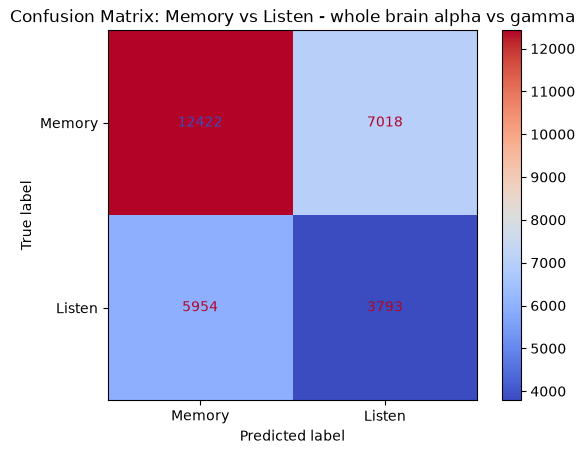

,precision,recall,f1-score,support
Listen,0.351,0.389,0.369,9747.000
Memory,0.676,0.639,0.657,19440.000
accuracy,0.556,0.556,0.556,0.556
macro avg,0.513,0.514,0.513,29187.000
weighted avg,0.567,0.556,0.561,29187.000


,model,metric,score
0,our-model,accuracy,0.572702
1,our-model,f1-macro,0.513000
2,our-model,f1-avg,0.561000


In [21]:
best_params = random_search.best_params_
accuracies, true, predicted = [], [], []
accuracy

for train, test in logo.split(X, Y, groups=group):
    classifier = RandomForestClassifier(**best_params, random_state=42, class_weight="balanced")
    classifier.fit(X.iloc[train], Y.iloc[train])
    prediction = classifier.predict(X.iloc[test])
    accuracy = accuracy_score(Y.iloc[test], prediction)
    accuracies.append(accuracy)
    true.extend(Y.iloc[test])
    predicted.extend(prediction)

cm = confusion_matrix(true, predicted, labels=["Memory", "Listen"])
ConfusionMatrixDisplay(cm, display_labels=["Memory", "Listen"]).plot(cmap="coolwarm")
plt.title("Confusion Matrix: Memory vs Listen - whole brain alpha vs gamma")
plt.show()

report = classification_report(true, predicted, output_dict = True)
report_df = pd.DataFrame(report).transpose().round(3)

scores_df.loc[len(scores_df)] = ["our-model", "accuracy", accuracy]
scores_df.loc[len(scores_df)] = ["our-model", "f1-macro", report_df.loc["macro avg", "f1-score"]]
scores_df.loc[len(scores_df)] = ["our-model", "f1-avg", report_df.loc["weighted avg", "f1-score"]]
display(report_df)
display(scores_df)

### Comparing with `DummyClassifier` as a baseline

In [22]:
logo = LeaveOneGroupOut()
dummy_true, dummy_pred, accuracy = [], [], []
accuracy
for train, test in logo.split(X, Y, groups=group):
    dummy = DummyClassifier(strategy='most_frequent')
    dummy.fit(X.iloc[train], Y.iloc[train])
    preds = dummy.predict(X.iloc[test])
    accuracy = accuracy_score(Y.iloc[test], preds)
    accuracies.append(accuracy)
    dummy_true.extend(Y.iloc[test])
    dummy_pred.extend(preds)
    
report = classification_report(dummy_true, dummy_pred, output_dict = True)
report_df = pd.DataFrame(report).transpose().round(3)
display(report_df)
scores_df.loc[len(scores_df)] = ["dummy-most-frequent", "accuracy", accuracy]
scores_df.loc[len(scores_df)] = ["dummy-most-frequent", "f1-macro", report_df.loc["macro avg", "f1-score"]]
scores_df.loc[len(scores_df)] = ["dummy-most-frequent", "f1-avg", report_df.loc["weighted avg", "f1-score"]]
display(scores_df)

c:\Users\atifm\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\atifm\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\atifm\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

,precision,recall,f1-score,support
Listen,0.000,0.000,0.000,9747.000
Memory,0.666,1.000,0.800,19440.000
accuracy,0.666,0.666,0.666,0.666
macro avg,0.333,0.500,0.400,29187.000
weighted avg,0.444,0.666,0.533,29187.000


,model,metric,score
0,our-model,accuracy,0.572702
1,our-model,f1-macro,0.513000
2,our-model,f1-avg,0.561000
3,dummy-most-frequent,accuracy,0.666667
4,dummy-most-frequent,f1-macro,0.400000
5,dummy-most-frequent,f1-avg,0.533000


In [23]:
logo = LeaveOneGroupOut()
dummy_true, dummy_pred = [], []

for train, test in logo.split(X, Y, groups=group):
    dummy = DummyClassifier(strategy='stratified')
    dummy.fit(X.iloc[train], Y.iloc[train])
    preds = dummy.predict(X.iloc[test])

    dummy_true.extend(Y.iloc[test])
    dummy_pred.extend(preds)

report = classification_report(dummy_true, dummy_pred, output_dict = True)
report_df = pd.DataFrame(report).transpose().round(3)
display(report_df)
scores_df.loc[len(scores_df)] = ["dummy-stratified", "accuracy", accuracy]
scores_df.loc[len(scores_df)] = ["dummy-stratified", "f1-macro", report_df.loc["macro avg", "f1-score"]]
scores_df.loc[len(scores_df)] = ["dummy-stratified", "f1-avg", report_df.loc["weighted avg", "f1-score"]]
display(scores_df)

,precision,recall,f1-score,support
Listen,0.335,0.335,0.335,9747.000
Memory,0.667,0.667,0.667,19440.000
accuracy,0.556,0.556,0.556,0.556
macro avg,0.501,0.501,0.501,29187.000
weighted avg,0.556,0.556,0.556,29187.000


,model,metric,score
0,our-model,accuracy,0.572702
1,our-model,f1-macro,0.513000
2,our-model,f1-avg,0.561000
3,dummy-most-frequent,accuracy,0.666667
4,dummy-most-frequent,f1-macro,0.400000
5,dummy-most-frequent,f1-avg,0.533000
6,dummy-stratified,accuracy,0.666667
7,dummy-stratified,f1-macro,0.501000
8,dummy-stratified,f1-avg,0.556000


(0.0, 1.0)

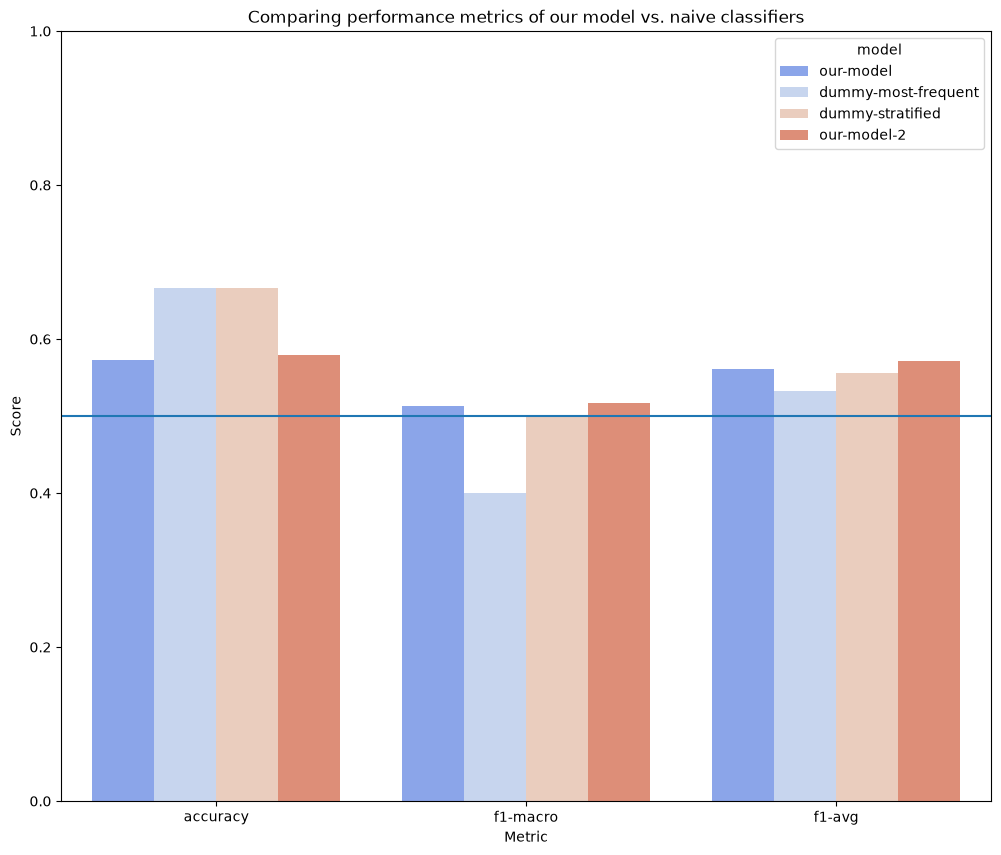

In [ ]:
plt.figure(figsize=(12, 10))
sns.barplot(x="metric", y="score", hue="model", data=scores_df, palette="coolwarm")
plt.title("Comparing performance metrics of our model vs. naive classifiers")
plt.xlabel("Metric")
plt.ylabel("Score")
plt.axhline(0.5)
plt.ylim(0, 1)

### Markdown conclusion

Running my model, I get the following scores. Mean accuracy = 0.572, f1_macro = 0.513, and f1_weighted_average = 0.561. When it comes to class-specific metrics, my model can predict the memory condition with a precision of 0.676, a recall of 0.639, and an f1 of 0.657. 

At first glance, this might look extremely promising, but note the class imbalance. We have roughly 2:1 ratio of memory to listen trials, so even with `class_weight = balanced`, we need to be careful before accepting this conclusion.

To set a quantifiable baseline, we will run a `DummyClassifier` to see if our model is performing better than a naive estimation. With a dummy classifier that always picks the most frequent, i.e. memory, we get a mean accuracy of 0.666, f1_macro = 0.4, and f1_weighted_average = 0.53. The accuracy of the dummy classifier is pulled up by the sheer proportion of the memory trials. 

Analysing another dummy classifier with a "stratified" strategy, where it guesses in proportion of the frequency of labels, it has a f1_macro of 0.50 and an f1_weighted_average of 0.56.

Concluding this section, my model performs slightly better than naive classifier. However, it is likely that we can improve our model and the following sections will work on that.

Below, I have a section to diagnose why my model is not performing better. As we see, between conditions, the whole brain alpha and gamma don't vary much.

### Diagnosing model performance

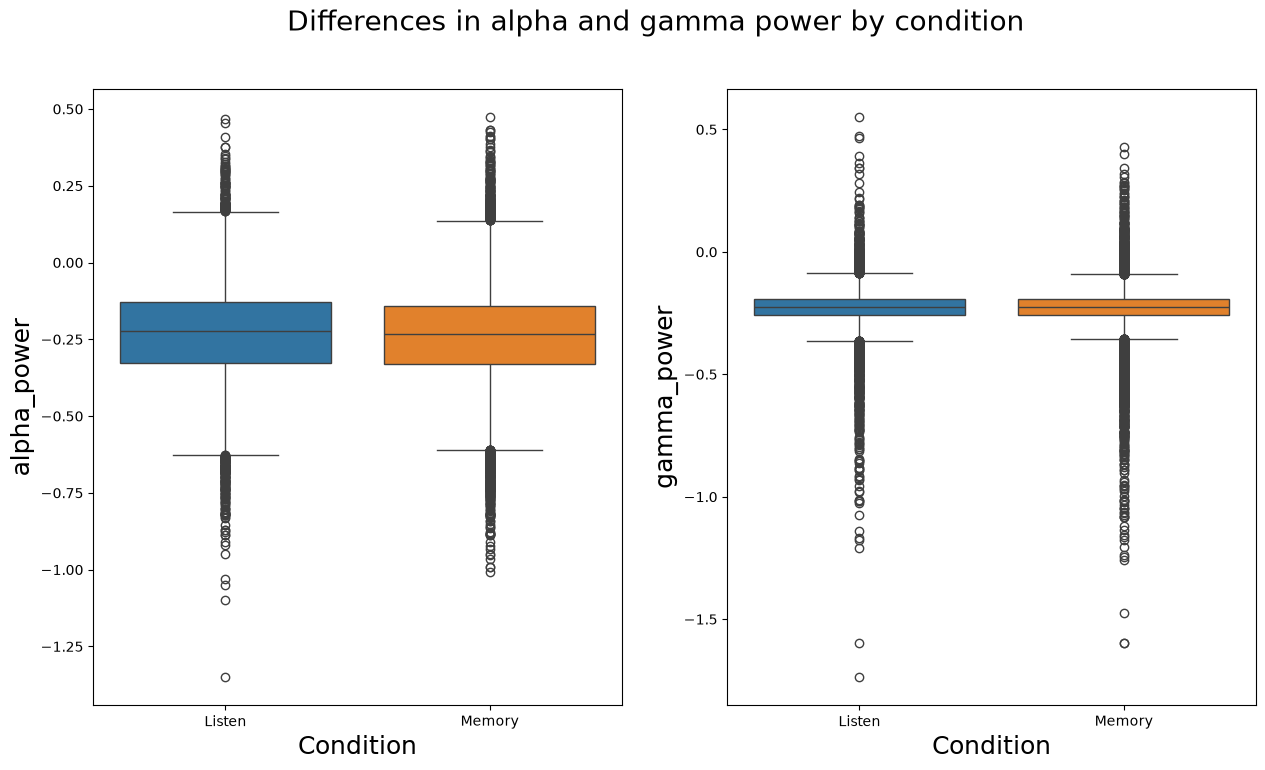

In [69]:
waves = ["alpha", "gamma"]
fig, ax = plt.subplots(1, 2, figsize=(15,8))

for column, wave in enumerate(waves):
        column_name = f"{wave}_power"
        sns.boxplot(x="condition", y=column_name, ax=ax[column], data=df_features, hue="condition")
        ax[column].set_ylabel(column_name, fontsize=18)
        ax[column].set_xlabel("Condition", fontsize=18)

plt.suptitle("Differences in alpha and gamma power by condition", fontsize=20)
plt.show()

## Classify: Determine condition (memory -vs- listen) from *ROI specific* alpha and gamma

We are going to redo our random forest, but this time with specific brain region powers instead of collapsing it to a global average. See below...

#### Compute powers 

In [ ]:
## LABEL = the event string like x500913
## CODE = a numeric code of the event

### SAME AS RANDOM FOREST 1
def parse_label(label):
    if not label.startswith(("5", "6")) or len(label) > 7 or len(label) < 6:
        print(f"Skipping this label: label {label} is invalid.")
        return None
    condition_flag = label[0]
    if condition_flag not in ("5", "6"):
        print(f"Error: label {label}. Condition flag is invalid")
    condition = "Memory" if condition_flag == "6" else "Listen"
    position = int(label[2:4])
    load = int(label[4:6])
    correct = None
    if condition == "Memory" and len(label) > 6:
        correct = "Correct" if label[6] == "1" else "Incorrect"
    return {"label" : label, "condition" : condition, "position" : position, "load" : load, "correct" : correct}

##################################################################################
# CHANNELS ARE: The channel names are: ['Fp1', 'Fz', 'F3', 'F7', 'FT9', 
# 'FC5', 'FC1', 'C3', 'T7', 'TP9', 'CP5', 'CP1', 'Pz', 'P3', 'P7', 
# 'O1', 'Oz', 'O2', 'P4', 'P8', 'TP10', 'CP6', 'CP2', 'Cz', 'C4', 
# 'T8', 'FT10', 'FC6', 'FC2', 'F4', 'F8', 'Fp2', 'AF7', 'AF3', 'AFz', 
# 'F1', 'F5', 'FT7', 'FC3', 'C1', 'C5', 'TP7', 'CP3', 'P1', 'P5', 'PO7', 
# 'PO3', 'POz', 'PO4', 'PO8', 'P6', 'P2', 'CPz', 'CP4', 'TP8', 'C6', 'C2', 
# 'FC4', 'FT8', 'F6', 'AF8', 'AF4', 'F2']

# Groups defined as per: https://neuroanalyzer.org/tutorials/locs.html
roi_groups = {
    "frontal" : ["Fp1", "Fp2", "F3", "F4", "F7", "F8", "Fz"], # Frontal lobe: Executive function, attention, decision-making, and working memory.
    "parietal" : ["P3", "P4", "P7", "P8", "Pz", "CP1", "CP2", "CP5", "CP6"], # Parietal lobe: Spatial orientation, sensory integration, and attention.
    "temporal": ["T7", "T8", "F7", "F8", "FT9", "FT10"],  # Temporal lobe: Auditory processing, language, and memory.
    "midline" : ["Fz", "Cz", "Pz", "Oz"],  # Midline structures: Default mode network, global brain states.
}

# Thus we will have:
# frontal_alpha, frontal_gamma
# parietal_alpha, parietal_gamma
# temporal_alpha, temporal_gamma
# midline_alpha, midline_gamma

def compute_power(epochs):
    freq = np.concatenate([np.arange(8, 13, 2), np.arange(30, 45, 2)]) # Alpha and Gamma. We are using 45 because we cutoff after that in our filter. Sparser sampling.
    n_cycles = freq / 2
    powers = epochs.compute_tfr(method="morlet", freqs=freq, n_cycles=n_cycles, decim=4, average=False)
    powers.data = powers.data.astype(np.float32)
    # Compute power relative to a time window
    powers.apply_baseline(baseline=(-1.5, -0.2), mode="logratio")
    
    alpha = powers.copy().crop(fmin=8, fmax=12)
    gamma = powers.copy().crop(fmin=30, fmax=44)

    # The key difference here: get ROI specific channels
    # I can do list construction one-line but I like this more
    ch_indices = []
    roi_powers = {}
    for roi_name, ch_list in roi_groups.items():
        ch_indices = []
        for ch in ch_list:
            if ch in powers.ch_names:
                ch_indices.append(powers.ch_names.index(ch))
        roi_powers[f"{roi_name}_alpha"] = alpha.data[:, ch_indices, :, :].mean(axis=(1, 2, 3))
        roi_powers[f"{roi_name}_gamma"] = gamma.data[:, ch_indices, :, :].mean(axis=(1, 2, 3))

    return pd.DataFrame(roi_powers)
##################################################################################

### SAME AS RANDOM FOREST 1
preprocessed_eeg_dir = "data/ica-excluded-eeg"
def process_participant_data(num):
    print(f"Processing epoch for participant {num}")
    eeg_file = f"{preprocessed_eeg_dir}/sub-0{num}-task-eeg_ica-cleaned.fif"
    if not os.path.exists(eeg_file):
        print(f"File {eeg_file} not found")
    else:
        raw = mne.io.read_raw_fif(eeg_file, preload=True)
        print(f"Read file {eeg_file}")
        events, event_id = mne.events_from_annotations(raw)
        code_to_label = {v : k for k, v in event_id.items()} # Reverse map. Get a dict where event "code" is KEY and "label" is VALUE

    # Loop through events in time series
    metadata, valid_event_indices = [], []
    for index, event in enumerate(events):
        event_description = parse_label(code_to_label[event[2]]) # Get the label from the event code which is in the 3rd position in "event"
        if event_description:
            metadata.append(event_description)
            valid_event_indices.append(index)
    
    metadata_df = pd.DataFrame(metadata) # Create metadata dataframe
    valid_events = events[valid_event_indices] # Get the list of clean event codes
    matched_event_labels = {k: v for k, v in event_id.items() if parse_label(k)} # Get the dictionary of event labels to codes, but only where it's valid label

    # Create epoch object: from 1.5 before to 3.5 as authors did
    epochs = mne.Epochs(raw, events=valid_events, event_id=matched_event_labels, tmin=-1.5, tmax=3.5, metadata=metadata_df)

    print(f"Start computing power for participant {num}")

    powers = compute_power(epochs)
    participant_df = epochs.metadata.reset_index(drop=True).copy()

    # Thus we will have:
    # frontal_alpha, frontal_gamma
    # parietal_alpha, parietal_gamma
    # temporal_alpha, temporal_gamma
    # midline_alpha, midline_gamma

    participant_df["frontal_alpha"] = powers["frontal_alpha"].values
    participant_df["frontal_gamma"] = powers["frontal_gamma"].values
    
    participant_df["parietal_alpha"] = powers["parietal_alpha"].values
    participant_df["parietal_gamma"] = powers["parietal_gamma"].values
    
    participant_df["temporal_alpha"] = powers["temporal_alpha"].values
    participant_df["temporal_gamma"] = powers["temporal_gamma"].values
    
    participant_df["midline_alpha"] = powers["midline_alpha"].values
    participant_df["midline_gamma"] = powers["midline_gamma"].values

    participant_df["participant"] = num

    print(f"\nBelow is dataframe for participant {num}")
    display(participant_df)
    return participant_df

participants_batch_1 = [32, 33, 34, 35, 36, 38, 39, 40, 41, 42]
participants_batch_2 = [43, 44, 45, 46, 47, 48, 49, 50, 51, 52]
participants_batch_3 = [53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65] # We will leave this out for lack of time

all_participants_2 = []

print(f"Starting batch_1. all_participants shape: {len(all_participants_2)}")
for participant in participants_batch_1:
    print(f"\n\nProcessing epoch and power for participant {participant}")
    # try:
    all_participants_2.append(process_participant_data(participant))
    # except Exception as error:
    #    print(f"Skipped participant {participant}. Error {error}.")

print(f"Starting batch_2. all_participants shape: {len(all_participants_2)}")
for participant in participants_batch_2:
    print(f"\nProcessing epoch and power for participant {participant}")
    try:
        all_participants_2.append(process_participant_data(participant))
    except Exception as error:
        print(f"Skipped participant {participant}. Error {error}.")

all_participants_df_2 = pd.concat(all_participants_2, ignore_index=True)
display(all_participants_df_2)
all_participants_df_2.to_csv("data/eeg-power-features-per-roi.csv", index=False)

#### Load Data

In [25]:
df_features_2 = pd.read_csv("data/eeg-power-features-per-roi.csv")
print(f"DF: {df_features_2.shape}")
display(df_features_2)

DF: (29187, 14)


,label,condition,position,load,correct,frontal_alpha,frontal_gamma,parietal_alpha,parietal_gamma,temporal_alpha,temporal_gamma,midline_alpha,midline_gamma,participant
0,500113,Listen,1,13,NaN,-0.025957,-0.183265,-0.009031,-0.205845,-0.157359,-0.194499,-0.096440,-0.160752,32
1,500213,Listen,2,13,NaN,-0.429560,-0.158683,-0.399298,-0.258114,-0.363661,-0.172133,-0.402520,-0.166223,32
2,500313,Listen,3,13,NaN,-0.422900,-0.244903,-0.425542,-0.174593,-0.307508,-0.225774,-0.410360,-0.229743,32
3,500413,Listen,4,13,NaN,-0.069365,-0.217401,-0.060179,-0.203852,0.063792,-0.215970,-0.118950,-0.210434,32
4,500513,Listen,5,13,NaN,-0.308645,-0.271917,-0.230197,-0.221062,-0.364749,-0.268459,-0.277217,-0.253627,32
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29182,500913,Listen,9,13,NaN,-0.010581,-0.196923,-0.168637,-0.183893,-0.322422,-0.167537,-0.125526,-0.169027,52
29183,501013,Listen,10,13,NaN,-0.073557,-0.247344,-0.187208,-0.239437,-0.049886,-0.277497,-0.070308,-0.279973,52
29184,501113,Listen,11,13,NaN,-0.529485,-0.233043,-0.374201,-0.290715,-0.287149,-0.341547,-0.557564,-0.325334,52
29185,501213,Listen,12,13,NaN,-0.076425,-0.231195,-0.211442,-0.188937,-0.180754,-0.186142,-0.172840,-0.222491,52


In [26]:
X = df_features_2[["frontal_alpha", "frontal_gamma",
    "parietal_alpha", "parietal_gamma",
    "temporal_alpha", "temporal_gamma",
    "midline_alpha", "midline_gamma"
]]

Y = df_features_2["condition"]
group = df_features_2["participant"]

display(X)
display(Y)
display(group)

,frontal_alpha,frontal_gamma,parietal_alpha,parietal_gamma,temporal_alpha,temporal_gamma,midline_alpha,midline_gamma
0,-0.025957,-0.183265,-0.009031,-0.205845,-0.157359,-0.194499,-0.096440,-0.160752
1,-0.429560,-0.158683,-0.399298,-0.258114,-0.363661,-0.172133,-0.402520,-0.166223
2,-0.422900,-0.244903,-0.425542,-0.174593,-0.307508,-0.225774,-0.410360,-0.229743
3,-0.069365,-0.217401,-0.060179,-0.203852,0.063792,-0.215970,-0.118950,-0.210434
4,-0.308645,-0.271917,-0.230197,-0.221062,-0.364749,-0.268459,-0.277217,-0.253627
...,...,...,...,...,...,...,...,...
29182,-0.010581,-0.196923,-0.168637,-0.183893,-0.322422,-0.167537,-0.125526,-0.169027
29183,-0.073557,-0.247344,-0.187208,-0.239437,-0.049886,-0.277497,-0.070308,-0.279973
29184,-0.529485,-0.233043,-0.374201,-0.290715,-0.287149,-0.341547,-0.557564,-0.325334
29185,-0.076425,-0.231195,-0.211442,-0.188937,-0.180754,-0.186142,-0.172840,-0.222491


0        Listen
1        Listen
2        Listen
3        Listen
4        Listen
          ...  
29182    Listen
29183    Listen
29184    Listen
29185    Listen
29186    Listen
Name: condition, Length: 29187, dtype: str

0        32
1        32
2        32
3        32
4        32
         ..
29182    52
29183    52
29184    52
29185    52
29186    52
Name: participant, Length: 29187, dtype: int64

#### Hyperparamter tuning

In [27]:
logo = LeaveOneGroupOut()

param_grid = {
    "n_estimators" : [50, 100, 200, 300, 400],
    "max_depth" : [10, 15, 20, 25, 30],
    "min_samples_split" : [2, 5, 10, 15, 20, 25]
}

random_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, class_weight="balanced"),
    param_distributions = param_grid,
    n_iter = 25,
    cv = list(logo.split(X, Y, groups=group)),
    scoring = "f1_macro",
    random_state = 42,
    n_jobs = -1,
)

random_search.fit(X, Y)
best_params = random_search.best_params_
print(f"The best params are: {best_params}")
print(f"The best sore is: {random_search.best_score_}")

The best params are: {'n_estimators': 400, 'min_samples_split': 15, 'max_depth': 10}
The best sore is: 0.5152142453829789


##### Hyperparameter tuning conclusion

With `n=25` run, I got: 
- The best params are: {'n_estimators': 400, 'min_samples_split': 15, 'max_depth': 10}
- The best sore is: 0.5152142453829789

I will use this `best_params` in runnning my random forest model.


#### Running my random forest

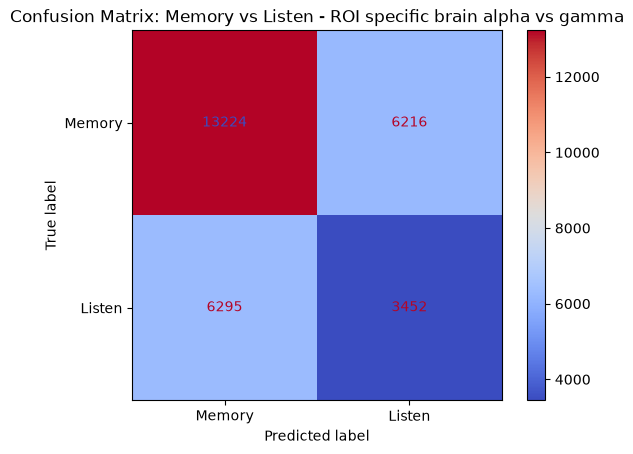

,precision,recall,f1-score,support
Listen,0.357,0.354,0.356,9747.000
Memory,0.677,0.680,0.679,19440.000
accuracy,0.571,0.571,0.571,0.571
macro avg,0.517,0.517,0.517,29187.000
weighted avg,0.570,0.571,0.571,29187.000


,model,metric,score
0,our-model,accuracy,0.572702
1,our-model,f1-macro,0.513000
2,our-model,f1-avg,0.561000
3,dummy-most-frequent,accuracy,0.666667
4,dummy-most-frequent,f1-macro,0.400000
5,dummy-most-frequent,f1-avg,0.533000
6,dummy-stratified,accuracy,0.666667
7,dummy-stratified,f1-macro,0.501000
8,dummy-stratified,f1-avg,0.556000
9,our-model-2,accuracy,0.578875


In [28]:
best_params = random_search.best_params_
accuracies, true, predicted = [], [], []
accuracy 
for train, test in logo.split(X, Y, groups=group):
    classifier = RandomForestClassifier(**best_params, random_state=42, class_weight="balanced")
    classifier.fit(X.iloc[train], Y.iloc[train])
    prediction = classifier.predict(X.iloc[test])
    accuracy = accuracy_score(Y.iloc[test], prediction)
    accuracies.append(accuracy)
    true.extend(Y.iloc[test])
    predicted.extend(prediction)

cm = confusion_matrix(true, predicted, labels=["Memory", "Listen"])
ConfusionMatrixDisplay(cm, display_labels=["Memory", "Listen"]).plot(cmap="coolwarm")
plt.title("Confusion Matrix: Memory vs Listen - ROI specific brain alpha vs gamma")
plt.show()

report = classification_report(true, predicted, output_dict = True)
report_df = pd.DataFrame(report).transpose().round(3)
display(report_df)

scores_df.loc[len(scores_df)] = ["our-model-2", "accuracy", accuracy]
scores_df.loc[len(scores_df)] = ["our-model-2", "f1-macro", report_df.loc["macro avg", "f1-score"]]
scores_df.loc[len(scores_df)] = ["our-model-2", "f1-avg", report_df.loc["weighted avg", "f1-score"]]
display(scores_df)

#### Comparing with whole brain alpha-gamma

,model,metric,score
0,our-model,accuracy,0.572702
1,our-model,f1-macro,0.513000
2,our-model,f1-avg,0.561000
9,our-model-2,accuracy,0.578875
10,our-model-2,f1-macro,0.517000
11,our-model-2,f1-avg,0.571000


(0.0, 1.0)

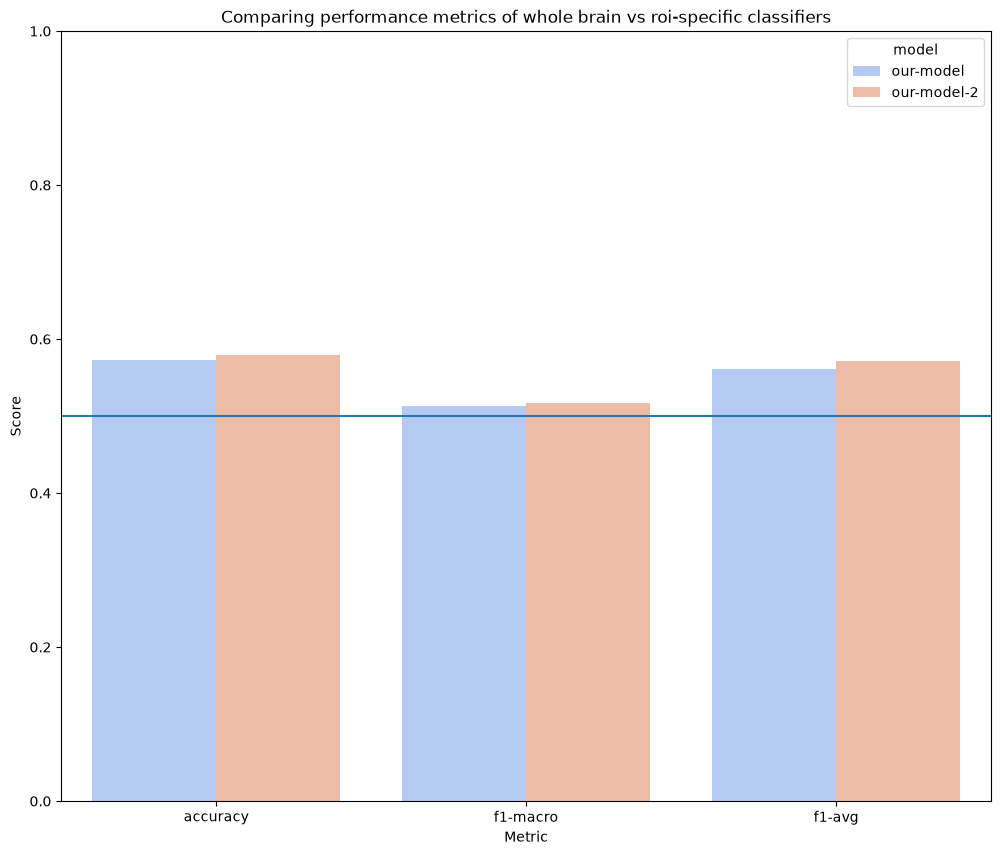

In [32]:
comparison_df = scores_df[scores_df["model"].isin(["our-model", "our-model-2"])]

display(comparison_df)

plt.figure(figsize=(12, 10))
sns.barplot(x="metric", y="score", hue="model", data=comparison_df, palette="coolwarm")
plt.title("Comparing performance metrics of whole brain vs roi-specific classifiers")
plt.xlabel("Metric")
plt.ylabel("Score")
plt.axhline(0.5)
plt.ylim(0, 1)

#### Markdown conclusion

As we see above, our ROI specific model performs slightly better than a whole-brain model likely because each brain region performs differently in different tasks. However, our correlation matrix below shows strong correlation between each region, thus, we still cannot reliably determine which condition the participant is in from ROI specific wave power alone. The boxplot also shows that there is not enough difference between ROI-specific wave powers across conditions to reliably create a model to determine condition from EEG.

#### Diagnosing model performance

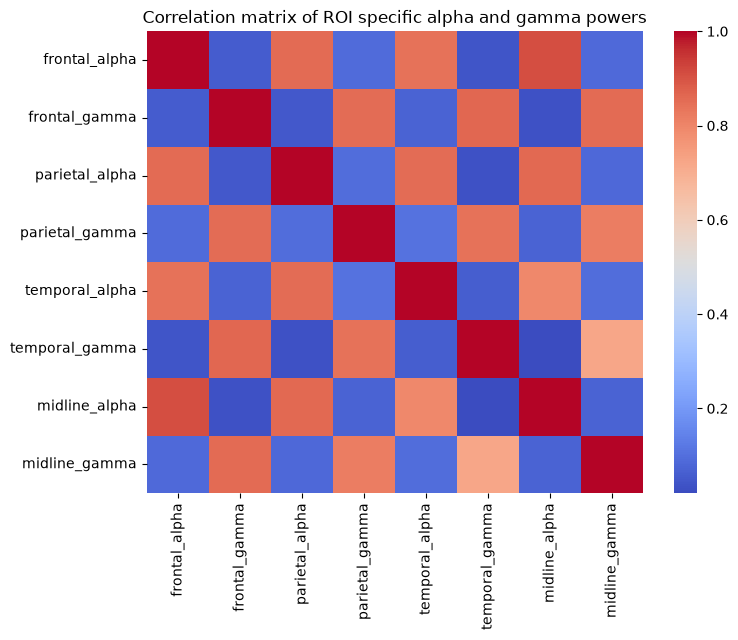

In [34]:
corr_matrix = df_features_2[["frontal_alpha", "frontal_gamma",
    "parietal_alpha", "parietal_gamma",
    "temporal_alpha", "temporal_gamma",
    "midline_alpha", "midline_gamma"
]].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, cmap="coolwarm", fmt=".2f")
plt.title("Correlation matrix of ROI specific alpha and gamma powers")
plt.show()


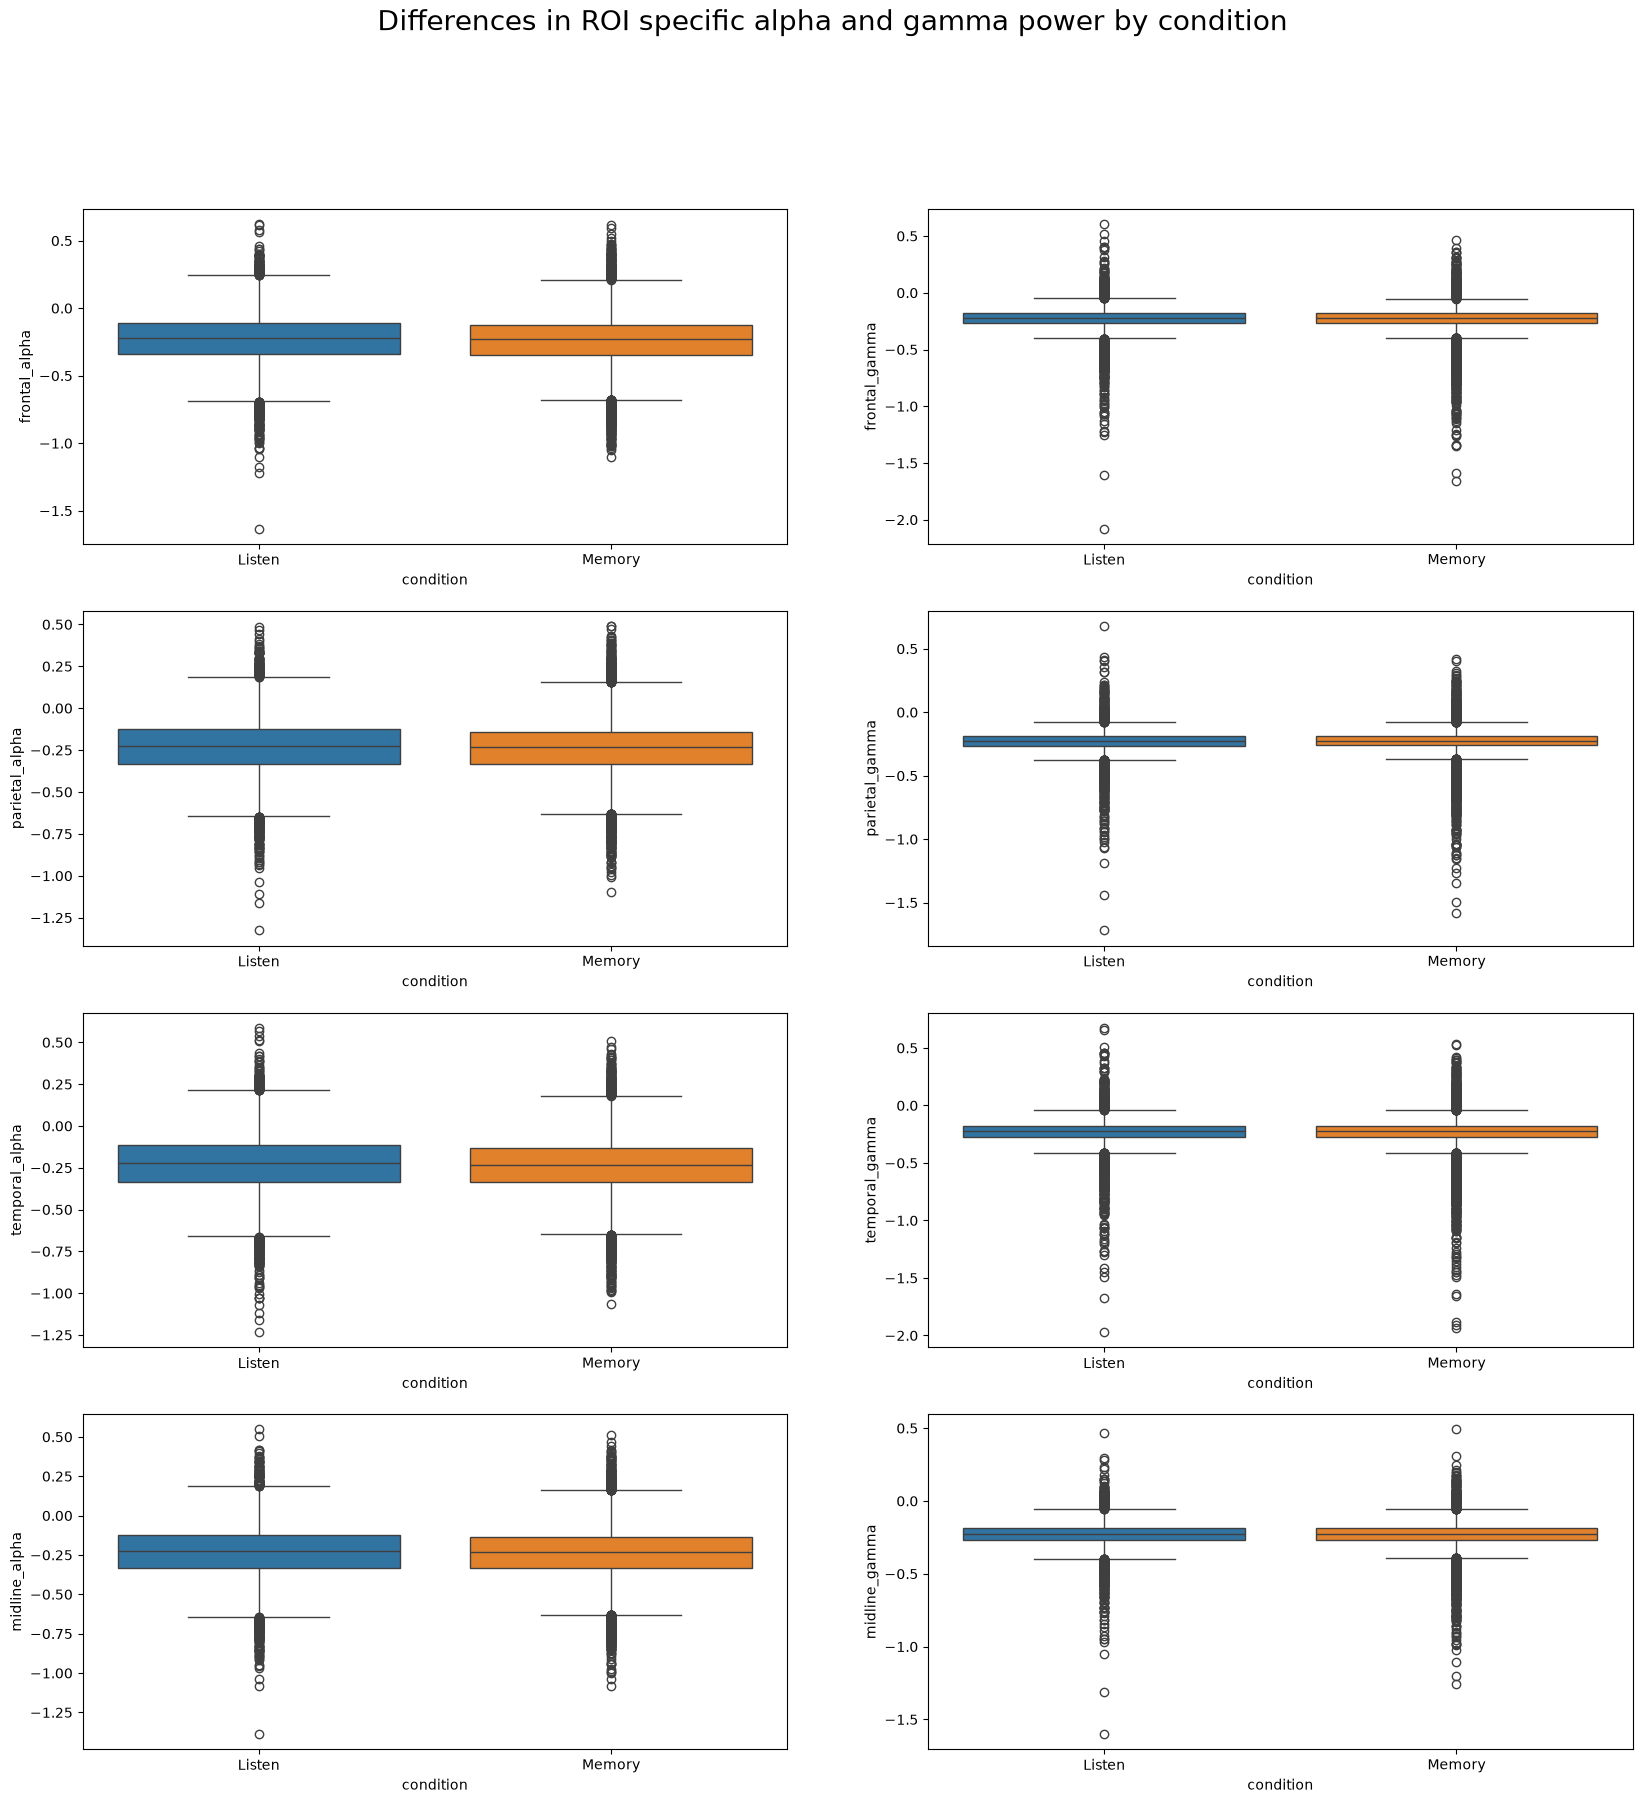

In [72]:
waves = ["alpha", "gamma"]
regions = ["frontal", "parietal", "temporal", "midline"]
fig, ax = plt.subplots(4, 2, figsize=(20,20))

for row, region in enumerate(regions):
    for column, wave in enumerate(waves):
        column_name =f"{region}_{wave}"
        sns.boxplot(x="condition", y=column_name, ax=ax[row, column], data=df_features_2, hue="condition")
plt.suptitle("Differences in ROI specific alpha and gamma power by condition", fontsize=20)
plt.show()

## [NOT USEFUL]: Classify: Determine if-correct from ROI specific alpha/gamma and load - almost completely dominated by load

### Load data

In [75]:
memory_only = df_features_2[df_features_2["condition"] == "Memory"].copy()

X = memory_only[["frontal_alpha", "frontal_gamma",
    "parietal_alpha", "parietal_gamma",
    "temporal_alpha", "temporal_gamma",
    "midline_alpha", "midline_gamma"
] + ["load"]]

Y = memory_only["correct"]
group = memory_only["participant"]

display(X)
display(Y)
display(group)

,frontal_alpha,frontal_gamma,parietal_alpha,parietal_gamma,temporal_alpha,temporal_gamma,midline_alpha,midline_gamma,load
27,0.193061,-0.081946,0.015769,-0.157055,0.074613,-0.205972,0.056585,-0.128515,5
28,0.038406,-0.317321,0.009146,-0.196372,-0.201308,-0.301459,-0.205581,-0.190985,5
29,-0.298564,-0.281461,-0.292050,-0.231724,-0.319654,-0.258346,-0.304738,-0.331221,5
30,-0.270205,-0.244397,-0.227371,-0.274063,-0.297191,-0.222777,-0.211354,-0.254895,5
31,-0.476281,-0.214254,-0.489742,-0.239469,-0.333310,-0.199434,-0.422091,-0.186475,5
...,...,...,...,...,...,...,...,...,...
29155,-0.299459,-0.208198,-0.343730,-0.233995,-0.250713,-0.291309,-0.327844,-0.176337,9
29156,-0.142492,-0.291920,-0.151020,-0.216910,-0.110901,-0.204035,-0.074573,-0.284885,9
29157,-0.241476,-0.241376,-0.199687,-0.222728,-0.195545,-0.205414,-0.255826,-0.241681,9
29158,-0.425693,-0.194492,-0.288186,-0.183964,-0.338112,-0.125381,-0.373091,-0.191510,9


27         Correct
28         Correct
29         Correct
30         Correct
31         Correct
           ...    
29155    Incorrect
29156    Incorrect
29157    Incorrect
29158    Incorrect
29159    Incorrect
Name: correct, Length: 19440, dtype: str

27       32
28       32
29       32
30       32
31       32
         ..
29155    52
29156    52
29157    52
29158    52
29159    52
Name: participant, Length: 19440, dtype: int64

### Hyperparameter tuning

In [76]:
logo = LeaveOneGroupOut()

param_grid = {
    "n_estimators" : [50, 100, 200, 300, 400],
    "max_depth" : [10, 15, 20, 25, 30],
    "min_samples_split" : [2, 5, 10, 15, 20, 25]
}

random_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, class_weight="balanced"),
    param_distributions = param_grid,
    n_iter = 25,
    cv = list(logo.split(X, Y, groups=group)),
    scoring = "f1_macro",
    random_state = 42,
    n_jobs = -1,
)

random_search.fit(X, Y)
best_params = random_search.best_params_
print(f"The best params are: {best_params}")
print(f"The best sore is: {random_search.best_score_}")

The best params are: {'n_estimators': 100, 'min_samples_split': 5, 'max_depth': 15}
The best sore is: 0.6699103762855374


### Running random forest

In [77]:
best_params = random_search.best_params_
accuracies, true, predicted = [], [], []
feature_importances = []

for train, test in logo.split(X, Y, groups=group):
    classifier = RandomForestClassifier(**best_params, random_state=42, class_weight="balanced")
    classifier.fit(X.iloc[train], Y.iloc[train])
    prediction = classifier.predict(X.iloc[test])
    accuracy = accuracy_score(Y.iloc[test], prediction)
    accuracies.append(accuracy)
    true.extend(Y.iloc[test])
    predicted.extend(prediction)
    feature_importances.append(classifier.feature_importances_)

mean = np.mean(feature_importances, axis=0)
stddev = np.mean(feature_importances, axis=0)

print(f"Mean accuracy: {np.mean(accuracies)}")
print(f"Classification report: {classification_report(true, predicted)}")
feature_importances_df = pd.DataFrame({
    "feature" : X.columns,
    "mean" : mean,
    "std. dev" : stddev
})

display(feature_importances_df)

Mean accuracy: 0.6885802469135802
Classification report:               precision    recall  f1-score   support

     Correct       0.75      0.50      0.60      8999
   Incorrect       0.66      0.85      0.75     10441

    accuracy                           0.69     19440
   macro avg       0.70      0.68      0.67     19440
weighted avg       0.70      0.69      0.68     19440



,feature,mean,std. dev
0,frontal_alpha,0.064516,0.064516
1,frontal_gamma,0.076648,0.076648
2,parietal_alpha,0.065627,0.065627
3,parietal_gamma,0.075657,0.075657
4,temporal_alpha,0.063927,0.063927
5,temporal_gamma,0.070391,0.070391
6,midline_alpha,0.063870,0.063870
7,midline_gamma,0.070695,0.070695
8,load,0.448669,0.448669


### Markdown conclusion

At first glance, it seems the model is performing well, with accuracy of 68.9%. However, if we analyse further and look at the feature importance table, we see that the classificaiton is dominated very heavily by load itself. The EEG powers contribute very little to the classification. Furthermore, the bar chart below shows how correct/incorrect drops heavily with load, so the correctness can be predicted almost entirely by load alone. Therefore, this is not a useful use case for EEG analysis.

<Axes: xlabel='load', ylabel='count'>

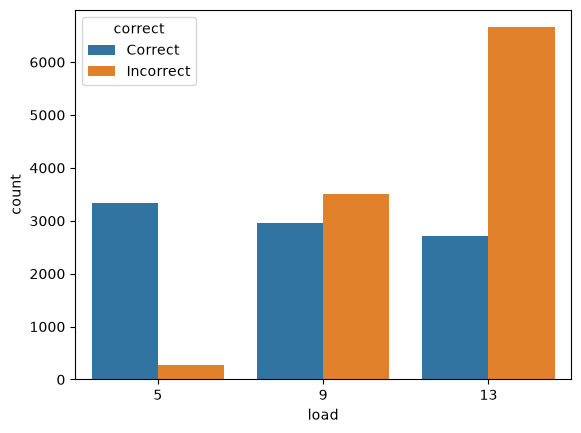

In [45]:
fig, ax = plt.subplots()

sns.countplot(x="load", hue="correct", data=memory_only)

## Classify: Determine condition from EEG (without baseline)

I was concerned that applying a baseline to the brain wave power was normalizing our values, leading to poor performance. That is why I tried a model without baseline. As we see, that wasn't a good move.

### Compute powers without baseline

In [ ]:
## LABEL = the event string like x500913
## CODE = a numeric code of the event

### SAME AS RANDOM FOREST 1
def parse_label(label):
    if not label.startswith(("5", "6")) or len(label) > 7 or len(label) < 6:
        print(f"Skipping this label: label {label} is invalid.")
        return None
    condition_flag = label[0]
    if condition_flag not in ("5", "6"):
        print(f"Error: label {label}. Condition flag is invalid")
    condition = "Memory" if condition_flag == "6" else "Listen"
    position = int(label[2:4])
    load = int(label[4:6])
    correct = None
    if condition == "Memory" and len(label) > 6:
        correct = "Correct" if label[6] == "1" else "Incorrect"
    return {"label" : label, "condition" : condition, "position" : position, "load" : load, "correct" : correct}

##################################################################################
# CHANNELS ARE: The channel names are: ['Fp1', 'Fz', 'F3', 'F7', 'FT9', 
# 'FC5', 'FC1', 'C3', 'T7', 'TP9', 'CP5', 'CP1', 'Pz', 'P3', 'P7', 
# 'O1', 'Oz', 'O2', 'P4', 'P8', 'TP10', 'CP6', 'CP2', 'Cz', 'C4', 
# 'T8', 'FT10', 'FC6', 'FC2', 'F4', 'F8', 'Fp2', 'AF7', 'AF3', 'AFz', 
# 'F1', 'F5', 'FT7', 'FC3', 'C1', 'C5', 'TP7', 'CP3', 'P1', 'P5', 'PO7', 
# 'PO3', 'POz', 'PO4', 'PO8', 'P6', 'P2', 'CPz', 'CP4', 'TP8', 'C6', 'C2', 
# 'FC4', 'FT8', 'F6', 'AF8', 'AF4', 'F2']

# Groups defined as per: https://neuroanalyzer.org/tutorials/locs.html
roi_groups = {
    "frontal" : ["Fp1", "Fp2", "F3", "F4", "F7", "F8", "Fz"], # Frontal lobe: Executive function, attention, decision-making, and working memory.
    "parietal" : ["P3", "P4", "P7", "P8", "Pz", "CP1", "CP2", "CP5", "CP6"], # Parietal lobe: Spatial orientation, sensory integration, and attention.
    "temporal": ["T7", "T8", "F7", "F8", "FT9", "FT10"],  # Temporal lobe: Auditory processing, language, and memory.
    "midline" : ["Fz", "Cz", "Pz", "Oz"],  # Midline structures: Default mode network, global brain states.
}

# Thus we will have:
# frontal_alpha, frontal_gamma
# parietal_alpha, parietal_gamma
# temporal_alpha, temporal_gamma
# midline_alpha, midline_gamma

def compute_power(epochs):
    freq = np.concatenate([np.arange(8, 13, 2), np.arange(30, 45, 2)]) # Alpha and Gamma. We are using 45 because we cutoff after that in our filter. Sparser sampling.
    n_cycles = freq / 2
    powers = epochs.compute_tfr(method="morlet", freqs=freq, n_cycles=n_cycles, decim=4, average=False)
    
    ### DO NOT DOWNSIZE! 
    ## powers.data = powers.data.astype(np.float32)
    ###
    
    ###
    ### DO NOT APPLY BASELINE!
    ###

    alpha = powers.copy().crop(fmin=8, fmax=12)
    gamma = powers.copy().crop(fmin=30, fmax=44)

    # The key difference here: get ROI specific channels
    # I can do list construction one-line but I like this more
    ch_indices = []
    roi_powers = {}
    for roi_name, ch_list in roi_groups.items():
        ch_indices = []
        for ch in ch_list:
            if ch in powers.ch_names:
                ch_indices.append(powers.ch_names.index(ch))
        roi_powers[f"{roi_name}_alpha"] = alpha.data[:, ch_indices, :, :].mean(axis=(1, 2, 3))
        roi_powers[f"{roi_name}_gamma"] = gamma.data[:, ch_indices, :, :].mean(axis=(1, 2, 3))

    return pd.DataFrame(roi_powers)
##################################################################################

### SAME AS RANDOM FOREST 1
preprocessed_eeg_dir = "data/ica-excluded-eeg"
def process_participant_data(num):
    print(f"Processing epoch for participant {num}")
    eeg_file = f"{preprocessed_eeg_dir}/sub-0{num}-task-eeg_ica-cleaned.fif"
    if not os.path.exists(eeg_file):
        print(f"File {eeg_file} not found")
    else:
        raw = mne.io.read_raw_fif(eeg_file, preload=True)
        print(f"Read file {eeg_file}")
        events, event_id = mne.events_from_annotations(raw)
        code_to_label = {v : k for k, v in event_id.items()} # Reverse map. Get a dict where event "code" is KEY and "label" is VALUE

    # Loop through events in time series
    metadata, valid_event_indices = [], []
    for index, event in enumerate(events):
        event_description = parse_label(code_to_label[event[2]]) # Get the label from the event code which is in the 3rd position in "event"
        if event_description:
            metadata.append(event_description)
            valid_event_indices.append(index)
    
    metadata_df = pd.DataFrame(metadata) # Create metadata dataframe
    valid_events = events[valid_event_indices] # Get the list of clean event codes
    matched_event_labels = {k: v for k, v in event_id.items() if parse_label(k)} # Get the dictionary of event labels to codes, but only where it's valid label

    # Create epoch object: from 1.5 before to 3.5 as authors did
    epochs = mne.Epochs(raw, events=valid_events, event_id=matched_event_labels, tmin=-1.5, tmax=3.5, metadata=metadata_df)

    print(f"Start computing power for participant {num}")

    powers = compute_power(epochs)
    participant_df = epochs.metadata.reset_index(drop=True).copy()

    # Thus we will have:
    # frontal_alpha, frontal_gamma
    # parietal_alpha, parietal_gamma
    # temporal_alpha, temporal_gamma
    # midline_alpha, midline_gamma

    participant_df["frontal_alpha"] = powers["frontal_alpha"].values
    participant_df["frontal_gamma"] = powers["frontal_gamma"].values
    
    participant_df["parietal_alpha"] = powers["parietal_alpha"].values
    participant_df["parietal_gamma"] = powers["parietal_gamma"].values
    
    participant_df["temporal_alpha"] = powers["temporal_alpha"].values
    participant_df["temporal_gamma"] = powers["temporal_gamma"].values
    
    participant_df["midline_alpha"] = powers["midline_alpha"].values
    participant_df["midline_gamma"] = powers["midline_gamma"].values

    participant_df["participant"] = num

    print(f"\nBelow is dataframe for participant {num}")
    display(participant_df)
    return participant_df

participants_batch_1 = [32, 33, 34, 35, 36, 38, 39, 40, 41, 42]
participants_batch_2 = [43, 44, 45, 46, 47, 48, 49, 50, 51, 52]
participants_batch_3 = [53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65] # We will leave this out for lack of time

all_participants_3 = []

print(f"Starting batch_1. all_participants shape: {len(all_participants_3)}")
for participant in participants_batch_1:
    print(f"\n\nProcessing epoch and power for participant {participant}")
    # try:
    all_participants_3.append(process_participant_data(participant))
    # except Exception as error:
    #    print(f"Skipped participant {participant}. Error {error}.")

print(f"Starting batch_2. all_participants shape: {len(all_participants_3)}")
for participant in participants_batch_2:
    print(f"\nProcessing epoch and power for participant {participant}")
    try:
        all_participants_3.append(process_participant_data(participant))
    except Exception as error:
        print(f"Skipped participant {participant}. Error {error}.")

all_participants_df_3 = pd.concat(all_participants_3, ignore_index=True)
display(all_participants_df_3)
all_participants_df_3.to_csv("data/eeg-power-features-per-roi-no-baseline.csv", index=False)

### Load data

In [ ]:
df_features_3 = pd.read_csv("data/eeg-power-features-per-roi-no-baseline.csv")
print(f"DF: {df_features_3.shape}")
display(df_features_3)

### Create feature matrix

In [ ]:
X = df_features_3[["frontal_alpha", "frontal_gamma",
    "parietal_alpha", "parietal_gamma",
    "temporal_alpha", "temporal_gamma",
    "midline_alpha", "midline_gamma"
]]

Y = df_features_3["condition"]
group = df_features_3["participant"]

display(X)
display(Y)
display(group)

### Hyperparamter tuning

In [51]:
logo = LeaveOneGroupOut()
accuracies, true, predicted = [], [], []

for train, test in logo.split(X, Y, groups=group):
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X.iloc[train])
    X_test_scaled = scaler.transform(X.iloc[test])
    classifier = RandomForestClassifier(n_estimators=100, random_state=42, class_weight="balanced")
    classifier.fit(X_train_scaled, Y.iloc[train])
    prediction = classifier.predict(X_test_scaled)
    accuracy = accuracy_score(Y.iloc[test], prediction)
    accuracies.append(accuracy)
    true.extend(Y.iloc[test])
    predicted.extend(prediction)

print(f"Mean accuracy: {np.mean(accuracies)}")
print(f"Classification report: {classification_report(true, predicted)}")

Mean accuracy: 0.5405998254146402
Classification report:               precision    recall  f1-score   support

      Listen       0.36      0.47      0.41      9747
      Memory       0.68      0.58      0.63     19440

    accuracy                           0.54     29187
   macro avg       0.52      0.52      0.52     29187
weighted avg       0.57      0.54      0.55     29187



### Run random forest

In [54]:
logo = LeaveOneGroupOut()
accuracies, true, predicted = [], [], []

for train, test in logo.split(X, Y, groups=group):
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X.iloc[train])
    X_test_scaled = scaler.transform(X.iloc[test])
    classifier = LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced")
    classifier.fit(X_train_scaled, Y.iloc[train])
    prediction = classifier.predict(X_test_scaled)
    accuracy = accuracy_score(Y.iloc[test], prediction)
    accuracies.append(accuracy)
    true.extend(Y.iloc[test])
    predicted.extend(prediction)

print(f"Mean accuracy: {np.mean(accuracies)}")
print(f"Classification report: {classification_report(true, predicted)}")

Mean accuracy: 0.48295236313754836
Classification report:               precision    recall  f1-score   support

      Listen       0.35      0.65      0.46      9747
      Memory       0.69      0.40      0.51     19440

    accuracy                           0.48     29187
   macro avg       0.52      0.52      0.48     29187
weighted avg       0.58      0.48      0.49     29187



### Markdown Conclusion

This model performs worse than chance, making multiple wrong classifications. As a result, we cannot reliably use this model. See below for a diagnosis on why this model fails.....

### Diagnosing model performance

In [ ]:
df_features_3["condition"].isna().sum()
display(X.describe())
print(X.isna().sum())

,frontal_alpha,frontal_gamma,parietal_alpha,parietal_gamma,temporal_alpha,temporal_gamma,midline_alpha,midline_gamma
count,2.918700e+04,2.918700e+04,2.918700e+04,2.918700e+04,2.918700e+04,2.918700e+04,2.918700e+04,2.918700e+04
mean,2.097507e-09,1.236198e-10,3.100704e-09,1.106548e-10,1.520538e-09,1.118074e-10,2.886853e-09,1.198578e-10
std,2.432736e-09,1.310786e-10,5.080436e-09,1.084513e-10,1.787226e-09,1.773390e-10,3.949039e-09,9.481595e-11
min,1.361158e-10,1.429762e-11,2.287658e-10,2.066096e-11,1.267302e-10,1.323926e-11,1.994536e-10,2.346424e-11
25%,6.955114e-10,7.051349e-11,8.519479e-10,6.393432e-11,5.378648e-10,5.924701e-11,9.361777e-10,6.691291e-11
50%,1.257387e-09,9.335943e-11,1.504076e-09,8.720711e-11,8.317297e-10,8.022964e-11,1.594400e-09,9.433353e-11
75%,2.425175e-09,1.355213e-10,2.987493e-09,1.277123e-10,1.653757e-09,1.200069e-10,2.936791e-09,1.336931e-10
max,1.858490e-08,3.995124e-09,4.326060e-08,3.825226e-09,1.560978e-08,9.513608e-09,2.875117e-08,1.386309e-09


frontal_alpha     0
frontal_gamma     0
parietal_alpha    0
parietal_gamma    0
temporal_alpha    0
temporal_gamma    0
midline_alpha     0
midline_gamma     0
dtype: int64


We first see if there are any strange or NAN values. There aren't but there is a reason that our model is still performing poorly. 
After we remove the baseline, we remove any concept of increase or decrease in power. This makes our model perform worse.